In [12]:
%matplotlib widget

In [13]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from g4beam import *
from scan import *
from scipy.optimize import differential_evolution
from matplotlib.cm import viridis
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import re
import sys
from pathlib import Path
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
import os
from tabulate import tabulate
import tempfile
import glob
import json
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

### Combining Multiple Elements of the Dispersion Suppressor

In [14]:
# If particles_after isn't updated with Z = 0.
def convertZ(input_file, output_file):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = "0"  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None
#convertZ("particles_afterupt.txt", "particles_after.txt")

## Wedge

In [15]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


In [16]:
# --------------- Calculation Functions -----------------
def read_g4bl_params(filename):
    """
    Reads 'param' definitions from a .g4bl file and returns a dict of parameter names and values.
    """
    params = {}
    pattern = re.compile(r"param\s+(?:-unset\s+)?(\w+)=([^\s#]+)")
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("param"):
                continue
            m = pattern.search(line)
            if m:
                key, val = m.groups()
                try:
                    params[key] = float(eval(val, {"__builtins__": None, "pi": math.pi}))
                except Exception:
                    params[key] = val  # keep as string if not numeric
    return params

# Compute wedge elements
def compute_wedge_geometry(params):
    """
    Given parameters like absLEN3, abshgt, abswidth, abshalfangle3, compute geometry info.
    """
    W = params.get("absLEN3")
    H = params.get("abshgt")
    L = params.get("abswidth")
    half_angle_deg = params.get("abshalfangle3")
    offset = params.get("absoffset3", 0)

    if L and half_angle_deg:
        half_angle_rad = math.radians(half_angle_deg)
        L_centerline = W / math.sin(half_angle_rad)

    return {
        "Length_Wedge": L,
        "Height_Base": H,
        "Width_Base": W,
        "Half-angle": half_angle_deg,
        "Centerline_Coords": L_centerline,
        "Offset": offset
    }

# Write values to the prepared G4BL template
def write_input_from_template(template_path, out_path, replacements):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

#### Wedge Parameters

In [17]:
# ---------------- USER CONFIG ----------------
G4BEAMLINE_CMD = "g4bl"
TEMPLATE_FILE = "G4_FinalCooling_dispsup_Template.g4bl"
OUTPUT_DIR = "dispsup_runs"
VD_FILENAME = "vd_dispsup.txt"  # When we sweep, we change this file
N_PARTICLES = 5000                  # increase for lower noise
G4BLFILE = f"G4_FinalCooling_dispsup_run"

os.makedirs(OUTPUT_DIR, exist_ok=True)

params = read_g4bl_params(TEMPLATE_FILE)
geom = compute_wedge_geometry(params)

print("Parameters found:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

print("Derived geometry:")
for k, v in geom.items():
    print(f"  {k:20s}: {v}")

Parameters found:
  zbegin          = 0.0
  steppingFormat  = N,GLOBAL,CL,STEP,VOL,PROCESS,P,KE,POLAR,B
  fieldVoxels     = 400,400,400
  maxStep         = 0.5
  minRangeCut     = 1.0
  nparticles      = {N_PARTICLES}
  beamfile        = particles_before.txt
  pi              = 3.141592654
  degrad          = $pi/180
  abshgt          = 10.0
  abswidth        = 100.0
  absLEN3         = 18.0
  abshalfangle3   = 45.0
  absoffset3      = 3.2
  wedge_z         = 0.5*$absLEN3
  VDRad           = 60.0
  wedgeAxis       = 0.0
  noWedge         = 0.0
Derived geometry:
  Length_Wedge        : 100.0
  Height_Base         : 10.0
  Width_Base          : 18.0
  Half-angle          : 45.0
  Centerline_Coords   : 25.455844122715714
  Offset              : 3.2


## Placing Elements

In [6]:
# Calculate all will-be-added parameters in the template
def add_missing_params(calcparams_given):
    GAP = 0.1  # in mm (can be up to 1.0 safely)
    
    L_Q1 = float(calcparams_given["Q1_length"])
    L_D1 = float(calcparams_given["Drift1_length"])
    L_Q2 = float(calcparams_given["Q2_length"])
    L_D2 = float(calcparams_given["Drift2_length"])
    L_B1 = float(calcparams_given["B1_length"])

    wedge_end = geom["Centerline_Coords"]
    Q1_z      = geom["Centerline_Coords"] + (L_Q1/2) + GAP
    Drift1_z = Q1_z + (L_Q1/2) + (L_D1/2) + GAP
    Q2_z     = Drift1_z + (L_D1/2) + (L_Q2/2) + GAP
    Drift2_z = Q2_z + (L_Q2/2) + (L_D2/2)+ GAP
    B1_z     = Drift2_z + (L_D2/2) + (L_B1/2) + GAP
    VD_z     = B1_z + (L_B1/2) + 10.0 + GAP

    Q1_end = Q1_z + (L_Q1/2)
    D1_end = Drift1_z + (L_D1/2)
    Q2_end = Q2_z + (L_Q2/2)
    D2_end = Drift2_z + (L_D2/2)
    B1_end = B1_z + (L_B1/2)

    add_params = {"wedge_end": wedge_end, "Q1_z": Q1_z, "Drift1_z": Drift1_z, "Q2_z": Q2_z, "Drift2_z":Drift2_z, "B1_z": B1_z,"VD_z": VD_z, 
            "B1_end": B1_end, "Q2_end": Q2_end,  "D1_end": D1_end, "Q1_end": Q1_end,  "D2_end": D2_end}

    calcparams_given.update(add_params)
    
    for k, v in calcparams_given.items():
        if k == "N_PARTICLES" or k == "VD_FILENAME":
            continue
        else:
            calcparams_given[k] = float(v)
    
    return calcparams_given

## Dave's Design

##### Plugging in a single Quadrupole and Sweeping

In [14]:
# Helper Function for finding where the zero value D is reached if it is
def find_first_zero_crossing(x_vals, y_vals):
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)
    for i in range(len(y_vals)-1):
        if y_vals[i] * y_vals[i+1] <= 0:
            x0, x1 = x_vals[i], x_vals[i+1]
            y0, y1 = y_vals[i], y_vals[i+1]
            if y1 != y0:
                return x0 - y0 * (x1 - x0) / (y1 - y0)
            return x0
    return np.nan

In [ ]:
# ======================================================================
# MAIN SWEEP STORAGE
# ======================================================================
quad_sweep_results = []
Q1_field_range = np.arange(-2.0, 2.0, 0.1)
Q1_length_range = np.linspace(100, 1000, 10) # in mm
Q1_thickness_range = np.linspace(100, 300, 10)
Q1_inner_radius_range = np.linspace(100, 300, 10)

# ======================================================================
# FULL QUADRUPOLE PARAMETER SCAN
# ======================================================================

for L_val in Q1_length_range:
    for thick_val in Q1_thickness_range:
        for r_in_val in Q1_inner_radius_range:

            # Prepare lists for this (L, thickness, radius) group
            Qfield_vals = []
            Dx_vals = []; Dy_vals = []; Dxp_vals = []; Dyp_vals = []
            emitx_vals = []; emity_vals = []; emitz_vals = []
            transmission_vals = []

            print(f"--- Scanning Q1_field for L={L_val:.1f} mm, t={thick_val:.1f} mm, rin={r_in_val:.1f} mm ---")

            for i, Q_val in enumerate(tqdm(Q1_field_range, desc="Q1 Field Sweep")):
                
                if L_val > 300:
                    import pickle
                    with open("EMERGENCY_DUMP.pkl", "wb") as f:
                        pickle.dump(quad_sweep_results, f)
                    print("EMERGENCY DUMP COMPLETE")
                    raise SystemExit
                # Remove old field map
                if os.path.exists("field_cell.dat"):
                    os.remove("field_cell.dat")

                # ----------------------------------------------------------
                # Build template parameters
                # ----------------------------------------------------------
                
                var_names = ["N_PARTICLES",  "B1_field", "B1_width", "B1_height", "B1_length", 
                "Q1_gradient", "Q1_length", "radius_q", "thickness", "Q1_z",
                "Q2_gradient", "Q2_length","Drift1_width", "Drift1_height", "Drift1_length",  
                "Drift2_width", "Drift2_height","Drift2_length", "VD_FILENAME"]
                
                xvec = np.array([
                    int(N_PARTICLES), 0.2101, 122.8026, 265.3664, 83.8629,
                    Q_val, L_val, r_in_val, thick_val, 10, 
                    -0.1835, 183.4535, 173.3462, 243.1225, 139.7656, 
                    191.618, 121.9246, 86.819, f"{OUTPUT_DIR}/{VD_FILENAME}_{L_val:.1f}_{thick_val:.1f}_{r_in_val:.1f}_{i}.txt"])

                params = {k: v for k, v in zip(var_names, xvec)}
                add_missing_params(params)

                # ----------------------------------------------------------
                # Write .g4bl input file
                # ----------------------------------------------------------
                g4file = f"{OUTPUT_DIR}/{G4BLFILE}_{L_val:.1f}_{thick_val:.1f}_{r_in_val:.1f}_{i}.g4bl"

                write_input_from_template(TEMPLATE_FILE, g4file, params)

                # ----------------------------------------------------------
                # Run G4Beamline
                # ----------------------------------------------------------
                subprocess.run(["g4bl", g4file], capture_output=True, text=True, check=True)

                out_file = params["VD_FILENAME"]
                df = read_trackfile(out_file)

                with open(out_file) as f:
                    N_out = sum(1 for line in f if not line.startswith("#") and line.strip())

                trans_percent = 100.0 * N_out / N_PARTICLES
                transmission_vals.append(trans_percent)

                # Compute optical parameters
                x_params, y_params, z_emit = calc_all_params(df)

                Qfield_vals.append(Q_val)
                Dx_vals.append(x_params[4])
                Dy_vals.append(y_params[4])
                Dxp_vals.append(x_params[5])
                Dyp_vals.append(y_params[5])

                emitx_vals.append(x_params[0])
                emity_vals.append(y_params[0])
                emitz_vals.append(z_emit)

            # ===============================================================
            # STORE THIS BLOCK OF SWEEP RESULTS
            # ===============================================================
            quad_sweep_results.append({
                "Q1_length": L_val,
                "Q1_thickness": thick_val,
                "Q1_inner_radius": r_in_val,

                "Q1_field": Qfield_vals,
                "Dx": Dx_vals,
                "Dy": Dy_vals,
                "Dxp": Dxp_vals,
                "Dyp": Dyp_vals,
                "emit_x": emitx_vals,
                "emit_y": emity_vals,
                "emit_z": emitz_vals,
                "transmission": transmission_vals
            })
            
            import pickle
            with open("quad_sweep_partial.pkl", "wb") as f:
                pickle.dump(quad_sweep_results, f)
            print("✨ Partial progress saved ✨")


In [18]:
import pickle
with open("quad_sweep_partial.pkl", "wb") as f:
    pickle.dump(quad_sweep_results, f)

In [18]:
with open("quad_sweep_partial.pkl", "rb") as f:
    saved_results = pickle.load(f)

print(f"Number of blocks saved: {len(saved_results)}")
print("Example first block keys:", saved_results[0].keys())
print("Length of Q1_field list in first block:", len(saved_results[0]["Q1_field"]))

Number of blocks saved: 300
Example first block keys: dict_keys(['Q1_length', 'Q1_thickness', 'Q1_inner_radius', 'Q1_field', 'Dx', 'Dy', 'Dxp', 'Dyp', 'emit_x', 'emit_y', 'emit_z', 'transmission'])
Length of Q1_field list in first block: 40


In [19]:
# Filter only fully complete blocks
complete_blocks = []
for block in quad_sweep_results:
    lengths = [len(block[key]) for key in ["Q1_field", "Dx", "Dy", "Dxp", "Dyp", "emit_x", "emit_y", "emit_z", "transmission"]]
    if all(l == lengths[0] for l in lengths):
        complete_blocks.append(block)

print(f"Saved {len(complete_blocks)} fully complete blocks out of {len(quad_sweep_results)} total.")

# Save filtered results
with open("quad_sweep_partial_complete.pkl", "wb") as f:
    pickle.dump(complete_blocks, f)

print("✨ Partial progress (complete blocks only) saved to quad_sweep_partial_complete.pkl ✨")

NameError: name 'quad_sweep_results' is not defined

In [20]:
def find_first_zero_crossing(x_vals, y_vals):
    """Return the first B where y crosses zero (linear interpolation)."""
    y_vals = np.array(y_vals)
    x_vals = np.array(x_vals)
    
    for i in range(len(y_vals)-1):
        if y_vals[i] * y_vals[i+1] <= 0:  # sign change or exact zero
            x0, x1 = x_vals[i], x_vals[i+1]
            y0, y1 = y_vals[i], y_vals[i+1]
            if y1 != y0:
                zero_cross = x0 - y0 * (x1 - x0) / (y1 - y0)
            else:
                zero_cross = x0
            return zero_cross
    return np.nan  # no zero-crossing found

# Build clean table
# Read the CSV file into a pandas DataFrame
with open('quad_sweep_partial_complete.pkl', 'rb') as file:
    sweep_results = pickle.load(file)
table_data= []
for res in sweep_results:
    L_val = res["Q1_length"]
    table_data.append({
        "Q1_length": L_val,
        "B_for_Dx0": find_first_zero_crossing(res["Q1_field"], res["Dx"]),
        "B_for_Dy0": find_first_zero_crossing(res["Q1_field"], res["Dy"]),
        "B_for_Dxp0": find_first_zero_crossing(res["Q1_field"], res["Dxp"]),
        "B_for_Dyp0": find_first_zero_crossing(res["Q1_field"], res["Dyp"])
    })

df_table = pd.DataFrame(table_data)
print(df_table)


     Q1_length  B_for_Dx0  B_for_Dy0  B_for_Dxp0  B_for_Dyp0
0        100.0        NaN        NaN         NaN         NaN
1        100.0        NaN        NaN         NaN         NaN
2        100.0        NaN        NaN         NaN         NaN
3        100.0        NaN        NaN         NaN         NaN
4        100.0        NaN        NaN         NaN         NaN
..         ...        ...        ...         ...         ...
295      300.0        NaN        NaN         NaN         NaN
296      300.0        NaN        NaN         NaN         NaN
297      300.0        NaN        NaN         NaN         NaN
298      300.0        NaN        NaN         NaN         NaN
299      300.0        NaN        NaN         NaN         NaN

[300 rows x 5 columns]


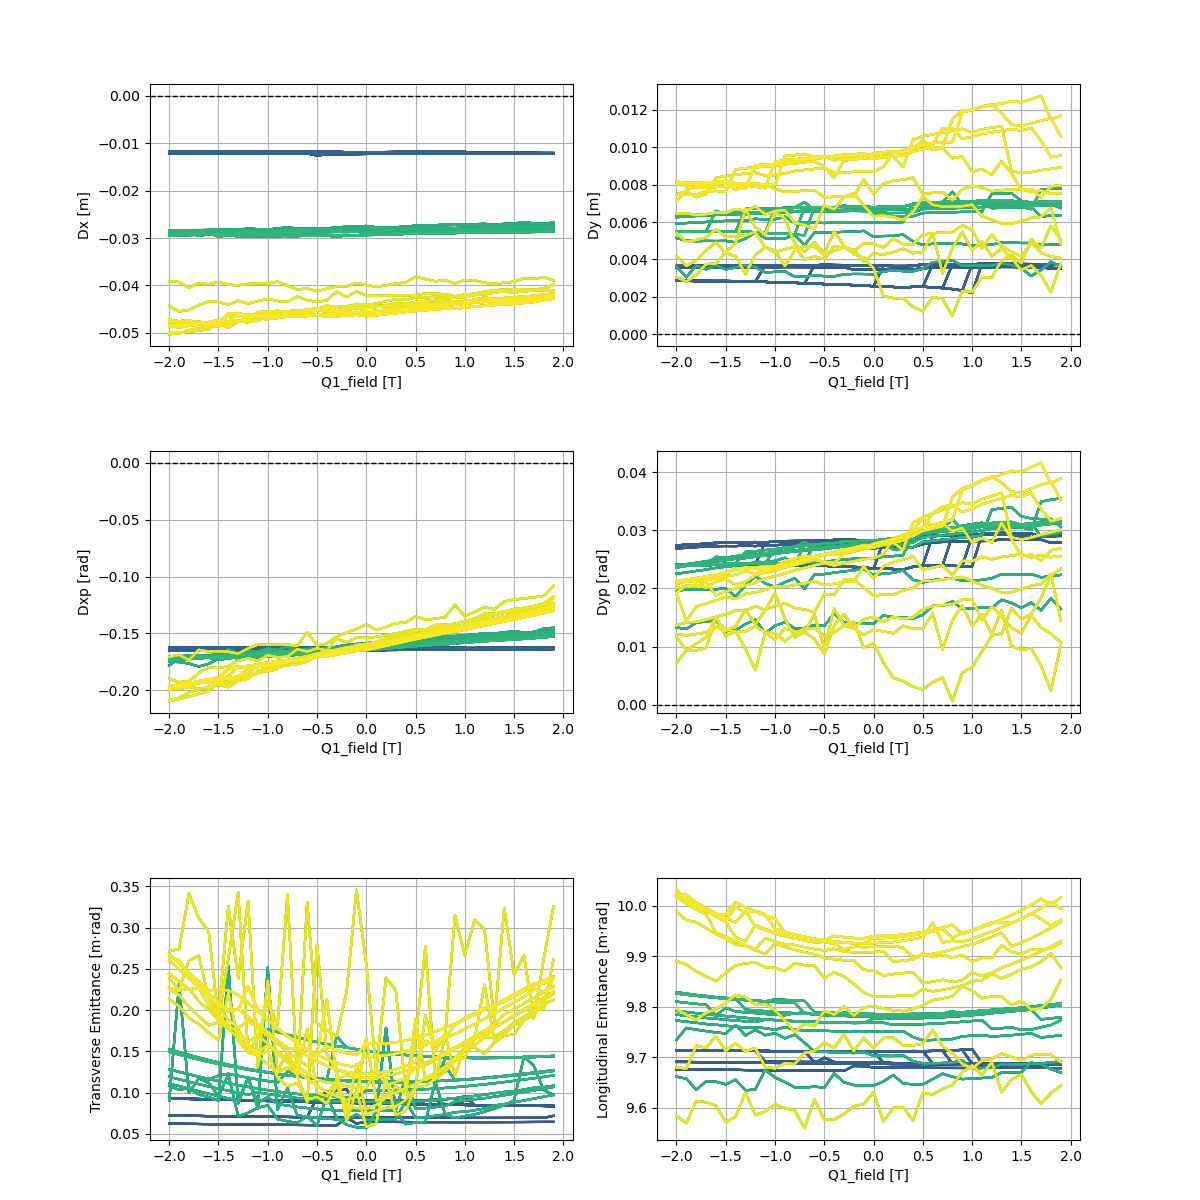

In [21]:
import mplcursors
colors = viridis(np.linspace(0, 1, len(sweep_results)))
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.flatten()

for j, (data_key, label) in enumerate([
    ("Dx", "Dx [m]"),
    ("Dy", "Dy [m]"),
    ("Dxp", "Dxp [rad]"),
    ("Dyp", "Dyp [rad]"),
    ("emit_xy", "Transverse Emittance [m·rad]"),
    ("emit_z", "Longitudinal Emittance [m·rad]")
]):
    ax = axs[j]

    for idx, res in enumerate(sweep_results):
        Q1_found_field = res["Q1_field"]
        if label == "Transverse Emittance [m·rad]":
            ax.plot(Q1_found_field, res["emit_x"], color=colors[idx], linestyle='-', label=f"t={res['Q1_thickness']:.1f} mm, rin={res['Q1_inner_radius']:.1f} mm x")

            # ax.plot(Q1_found_field, res["emit_y"], color=colors[idx], linestyle='--', label=f"t={res['Q1_thickness']:.1f} mm y")
        else:
            ax.plot(Q1_found_field, res[data_key], color=colors[idx], label=f"t={res['Q1_thickness']:.1f} mm, rin={res['Q1_inner_radius']:.1f}")
    
    
    
    if "D" in label:
        ax.axhline(0, color='k', linestyle='--', linewidth=1)

        #
        # if label == "Dxp [rad]" or label == "Dyp [rad]":

            # ax.set_ylim(-0.55, 0.25)
        # elif label == "Dx [m]" or label == "Dy [m]":
            # ax.set_ylim(-0.01, 0.01)

    ax.set_xlabel("Q1_field [T]")
    ax.set_ylabel(label)
    ax.grid(True)

# --- Create first legend for axs[0] (top center)
handles0, labels0 = axs[0].get_legend_handles_labels()
# fig.legend(handles0, labels0, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.0), fontsize=10)

# --- Create second legend for axs[5] (center gap between rows)
handles5, labels5 = axs[4].get_legend_handles_labels()
# fig.legend(handles5, labels5, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.27), fontsize=10)

# --- Adjust general subplot layout
fig.subplots_adjust(hspace=0.4, top=0.93, bottom=0.1)
cursor = mplcursors.cursor(hover=True)
@cursor.connect("add")
def on_add(sel):
    sel.annotation.set_text(sel.artist.get_label())
# --- Push last two plots down slightly
for ax in axs[4:]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.05, pos.width, pos.height])  # move down 5%

plt.savefig("Q1.png")
plt.show()
